<a href="https://colab.research.google.com/github/ARehman007-max/internship/blob/main/intern_assig_2_End_to_End_Regression_Project_Insurance_Cost_Prediction_%E2%80%94_From_Raw_Data_to_a_Deployable_Model_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import io
from google.colab import files
uploaded=files.upload()

Saving insurance.csv to insurance.csv


In [2]:
df=pd.read_csv(io.BytesIO(uploaded['insurance.csv']))
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [3]:
# Cell 1: Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.pipeline import make_pipeline
import io
from google.colab import files
import joblib
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

In [5]:
# Cell 3: Data Exploration - Basic Info and Statistics
print("="*50)
print("DATA EXPLORATION")
print("="*50)

# Display first few rows
print("\nFirst 5 rows of the dataset:")
print(df.head())

# Check data types
print("\nColumn data types:")
print(df.dtypes)

# Summary statistics
print("\nSummary statistics for numerical columns:")
print(df.describe())

# Check for missing values
print("\nMissing values count:")
print(df.isnull().sum())

# Check for duplicates
print(f"\nNumber of duplicate rows: {df.duplicated().sum()}")

DATA EXPLORATION

First 5 rows of the dataset:
   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520

Column data types:
age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

Summary statistics for numerical columns:
               age          bmi     children       charges
count  1338.000000  1338.000000  1338.000000   1338.000000
mean     39.207025    30.663397     1.094918  13270.422265
std      14.049960     6.098187     1.205493  12110.011237
min      18.000000    15.960000     0.000000   1121.873900
25%      27.000000    26.296250     0.000000   4740.28715

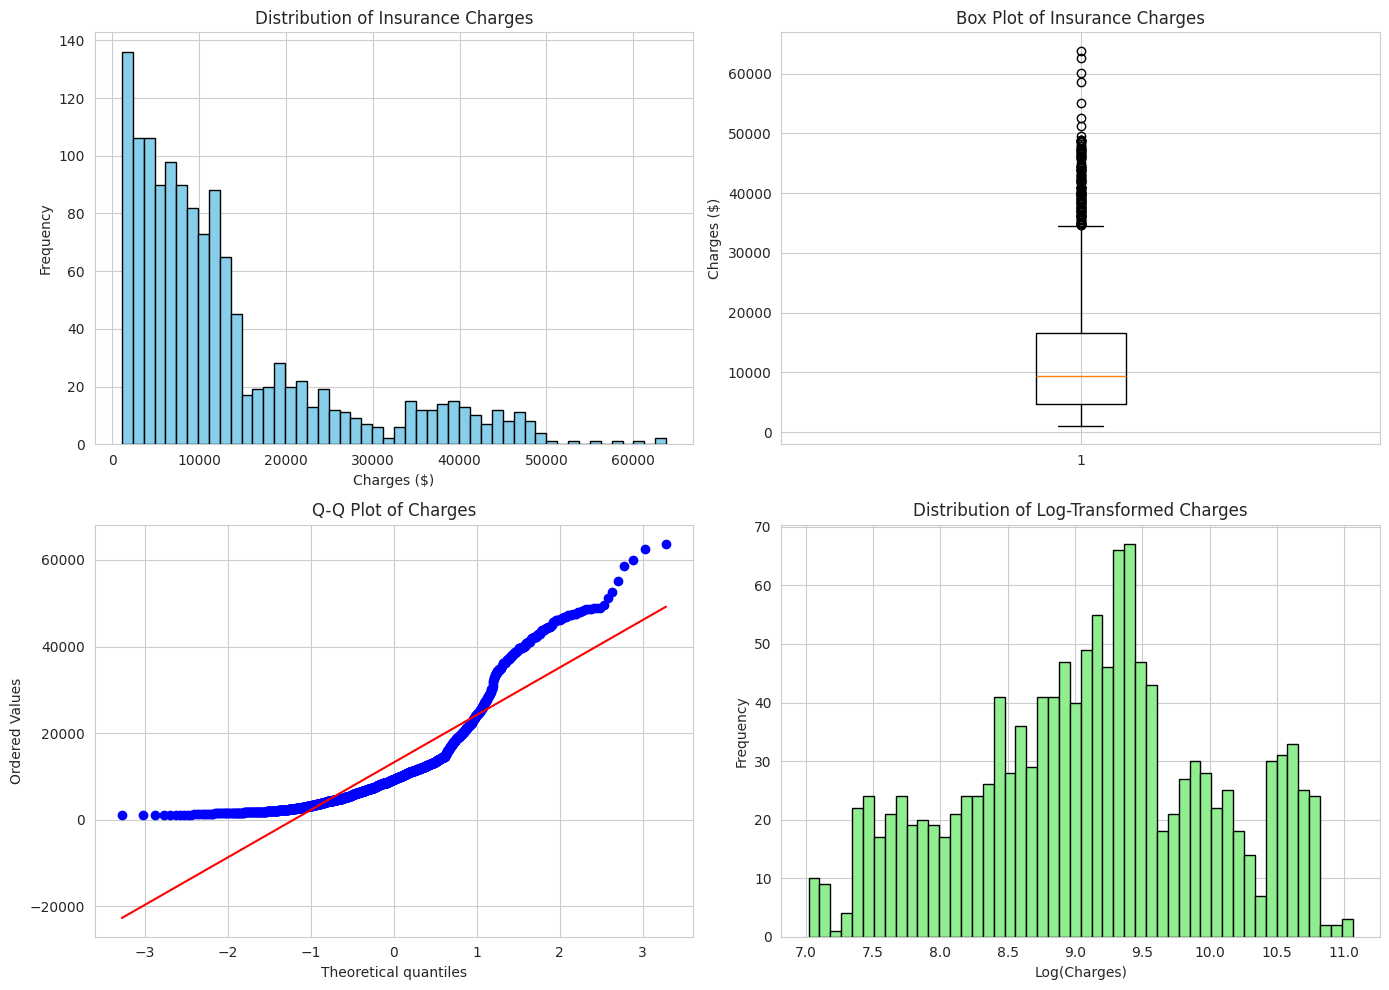


Skewness of charges: 1.52
Skewness of log-transformed charges: -0.09


In [6]:
# Cell 4: Exploratory Data Analysis - Target Variable Distribution
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Distribution of charges
axes[0, 0].hist(df['charges'], bins=50, color='skyblue', edgecolor='black')
axes[0, 0].set_title('Distribution of Insurance Charges')
axes[0, 0].set_xlabel('Charges ($)')
axes[0, 0].set_ylabel('Frequency')

# Box plot of charges
axes[0, 1].boxplot(df['charges'])
axes[0, 1].set_title('Box Plot of Insurance Charges')
axes[0, 1].set_ylabel('Charges ($)')

# QQ plot to check normality
from scipy import stats
stats.probplot(df['charges'], dist="norm", plot=axes[1, 0])
axes[1, 0].set_title('Q-Q Plot of Charges')

# Log-transformed charges
log_charges = np.log(df['charges'])
axes[1, 1].hist(log_charges, bins=50, color='lightgreen', edgecolor='black')
axes[1, 1].set_title('Distribution of Log-Transformed Charges')
axes[1, 1].set_xlabel('Log(Charges)')
axes[1, 1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

# Calculate skewness
skewness = df['charges'].skew()
print(f"\nSkewness of charges: {skewness:.2f}")
print(f"Skewness of log-transformed charges: {log_charges.skew():.2f}")

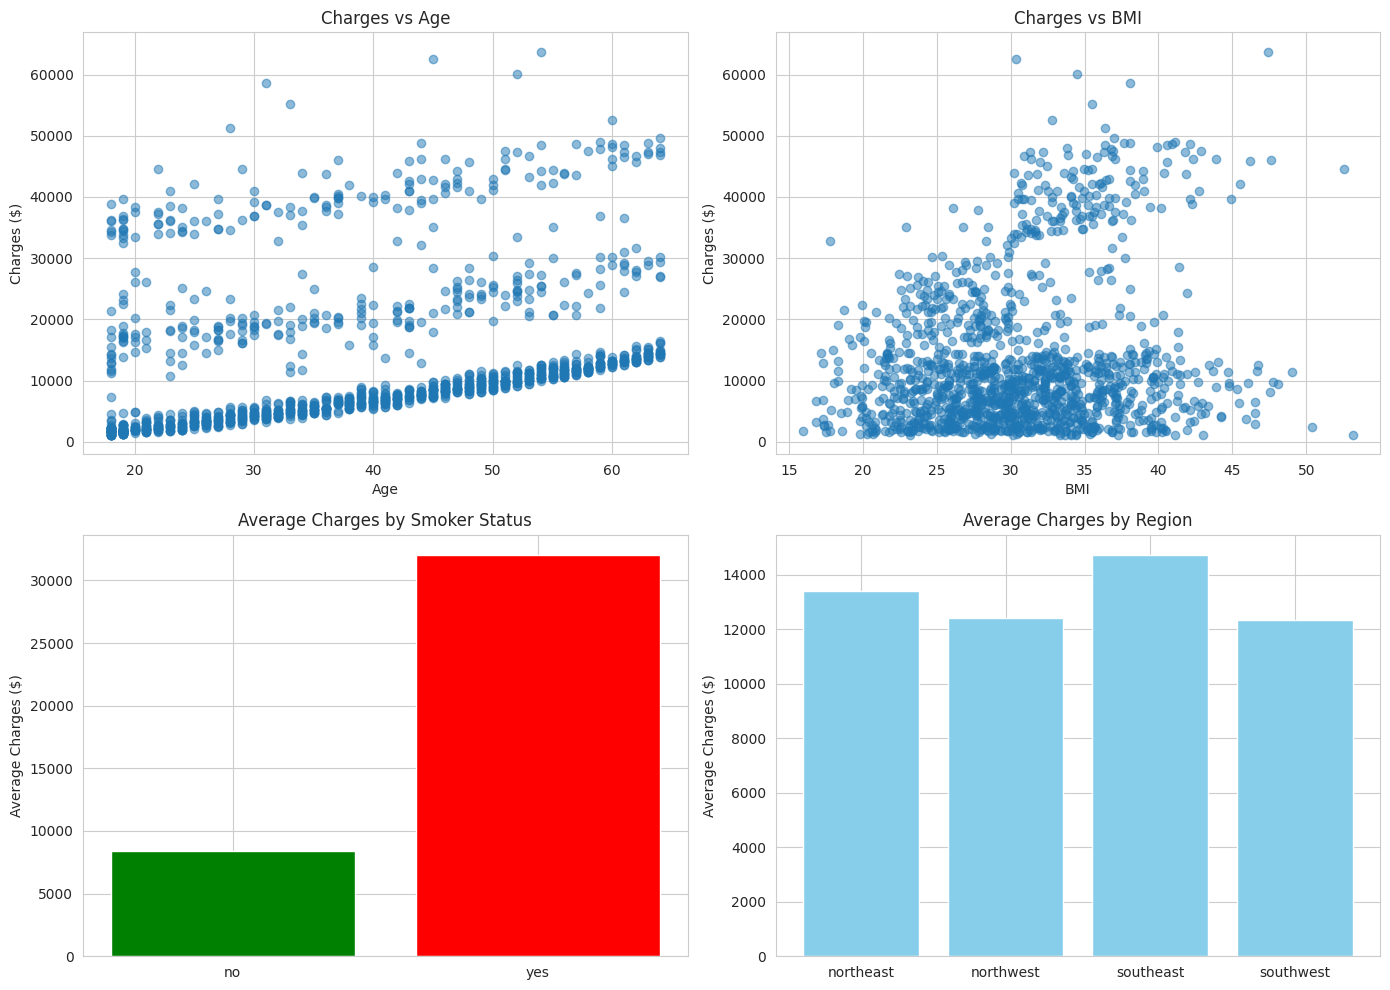

In [7]:
# Cell 5: EDA - Relationship with Key Features
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Charges vs Age
axes[0, 0].scatter(df['age'], df['charges'], alpha=0.5)
axes[0, 0].set_title('Charges vs Age')
axes[0, 0].set_xlabel('Age')
axes[0, 0].set_ylabel('Charges ($)')

# Charges vs BMI
axes[0, 1].scatter(df['bmi'], df['charges'], alpha=0.5)
axes[0, 1].set_title('Charges vs BMI')
axes[0, 1].set_xlabel('BMI')
axes[0, 1].set_ylabel('Charges ($)')

# Charges by Smoker Status
smoker_charges = df.groupby('smoker')['charges'].mean()
axes[1, 0].bar(smoker_charges.index, smoker_charges.values, color=['green', 'red'])
axes[1, 0].set_title('Average Charges by Smoker Status')
axes[1, 0].set_ylabel('Average Charges ($)')

# Charges by Region
region_charges = df.groupby('region')['charges'].mean()
axes[1, 1].bar(region_charges.index, region_charges.values, color='skyblue')
axes[1, 1].set_title('Average Charges by Region')
axes[1, 1].set_ylabel('Average Charges ($)')

plt.tight_layout()
plt.show()

In [8]:
# Cell 6: Feature Engineering
print("="*50)
print("FEATURE ENGINEERING")
print("="*50)

# Create a copy of the dataframe for feature engineering
df_engineered = df.copy()

# Drop duplicates if any
df_engineered = df_engineered.drop_duplicates()

# 1. Encode categorical variables
# For 'sex' and 'smoker' - Binary encoding (label encoding)
# Justification: These are binary categorical variables
df_engineered['sex_encoded'] = (df_engineered['sex'] == 'male').astype(int)
df_engineered['smoker_encoded'] = (df_engineered['smoker'] == 'yes').astype(int)

# For 'region' - One-hot encoding
# Justification: This is a nominal variable with multiple categories
region_dummies = pd.get_dummies(df_engineered['region'], prefix='region')
df_engineered = pd.concat([df_engineered, region_dummies], axis=1)

# 2. Create derived features
# BMI Category
def categorize_bmi(bmi):
    if bmi < 18.5:
        return 'underweight'
    elif bmi < 25:
        return 'normal'
    elif bmi < 30:
        return 'overweight'
    else:
        return 'obese'

df_engineered['bmi_category'] = df_engineered['bmi'].apply(categorize_bmi)
bmi_dummies = pd.get_dummies(df_engineered['bmi_category'], prefix='bmi_cat')
df_engineered = pd.concat([df_engineered, bmi_dummies], axis=1)

# Interaction feature: smoker and age
df_engineered['smoker_age_interaction'] = df_engineered['smoker_encoded'] * df_engineered['age']

# Interaction feature: smoker and BMI
df_engineered['smoker_bmi_interaction'] = df_engineered['smoker_encoded'] * df_engineered['bmi']

# Age squared (for potential non-linear relationships)
df_engineered['age_squared'] = df_engineered['age'] ** 2
df_engineered['bmi_squared'] = df_engineered['bmi'] ** 2

# 3. Log transform the target variable
df_engineered['log_charges'] = np.log(df_engineered['charges'])

print("Feature engineering completed!")
print(f"New shape: {df_engineered.shape}")
print("\nNew features created:")
new_features = ['sex_encoded', 'smoker_encoded', 'region_northeast', 'region_northwest',
                'region_southeast', 'region_southwest', 'bmi_cat_underweight', 'bmi_cat_normal',
                'bmi_cat_overweight', 'bmi_cat_obese', 'smoker_age_interaction',
                'smoker_bmi_interaction', 'age_squared', 'bmi_squared', 'log_charges']
print(new_features)

FEATURE ENGINEERING
Feature engineering completed!
New shape: (1337, 23)

New features created:
['sex_encoded', 'smoker_encoded', 'region_northeast', 'region_northwest', 'region_southeast', 'region_southwest', 'bmi_cat_underweight', 'bmi_cat_normal', 'bmi_cat_overweight', 'bmi_cat_obese', 'smoker_age_interaction', 'smoker_bmi_interaction', 'age_squared', 'bmi_squared', 'log_charges']


In [9]:
# Cell 7: Prepare features for modeling
# Define feature columns for modeling
feature_columns = ['age', 'sex_encoded', 'bmi', 'children', 'smoker_encoded',
                   'region_northeast', 'region_northwest', 'region_southeast', 'region_southwest',
                   'bmi_cat_underweight', 'bmi_cat_normal', 'bmi_cat_overweight', 'bmi_cat_obese',
                   'smoker_age_interaction', 'smoker_bmi_interaction', 'age_squared', 'bmi_squared']

X = df_engineered[feature_columns]
y_log = df_engineered['log_charges']
y_original = df_engineered['charges']

# Scale features for better model performance
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=feature_columns)

print("Features prepared for modeling:")
print(f"X shape: {X_scaled.shape}")
print(f"y (log-transformed) shape: {y_log.shape}")

Features prepared for modeling:
X shape: (1337, 17)
y (log-transformed) shape: (1337,)


In [10]:
# Cell 8: Train-Test Split
X_train, X_test, y_train_log, y_test_log, y_train_orig, y_test_orig = train_test_split(
    X_scaled, y_log, y_original, test_size=0.2, random_state=42
)

print("="*50)
print("MODEL BUILDING")
print("="*50)
print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")

MODEL BUILDING
Training set size: 1069 samples
Test set size: 268 samples


In [11]:
# Cell 9: Model 1 - Simple Linear Regression (using most predictive feature)
# Based on EDA, smoker status appears to be the most predictive feature
print("Model 1: Simple Linear Regression (Smoker Status)")
print("-" * 40)

# Prepare data for simple linear regression
X_train_simple = X_train[['smoker_encoded']]
X_test_simple = X_test[['smoker_encoded']]

# Train model
simple_model = LinearRegression()
simple_model.fit(X_train_simple, y_train_log)

# Predictions
y_pred_simple_log = simple_model.predict(X_test_simple)
y_pred_simple = np.exp(y_pred_simple_log)  # Transform back to original scale

# Evaluate
r2_simple = r2_score(y_test_orig, y_pred_simple)
mae_simple = mean_absolute_error(y_test_orig, y_pred_simple)
mse_simple = mean_squared_error(y_test_orig, y_pred_simple)
rmse_simple = np.sqrt(mse_simple)

print(f"R² Score: {r2_simple:.4f}")
print(f"MAE: ${mae_simple:,.2f}")
print(f"MSE: {mse_simple:,.2f}")
print(f"RMSE: ${rmse_simple:,.2f}")

Model 1: Simple Linear Regression (Smoker Status)
----------------------------------------
R² Score: 0.6357
MAE: $5,979.67
MSE: 66,945,660.04
RMSE: $8,182.03


In [12]:
# Cell 10: Model 2 - Multiple Linear Regression
print("\nModel 2: Multiple Linear Regression (All Features)")
print("-" * 40)

# Train model
multiple_model = LinearRegression()
multiple_model.fit(X_train, y_train_log)

# Predictions
y_pred_multiple_log = multiple_model.predict(X_test)
y_pred_multiple = np.exp(y_pred_multiple_log)

# Evaluate
r2_multiple = r2_score(y_test_orig, y_pred_multiple)
mae_multiple = mean_absolute_error(y_test_orig, y_pred_multiple)
mse_multiple = mean_squared_error(y_test_orig, y_pred_multiple)
rmse_multiple = np.sqrt(mse_multiple)

print(f"R² Score: {r2_multiple:.4f}")
print(f"MAE: ${mae_multiple:,.2f}")
print(f"MSE: {mse_multiple:,.2f}")
print(f"RMSE: ${rmse_multiple:,.2f}")


Model 2: Multiple Linear Regression (All Features)
----------------------------------------
R² Score: 0.8442
MAE: $2,870.56
MSE: 28,622,316.56
RMSE: $5,349.98


In [13]:
# Cell 11: Model 3 - Polynomial Regression
print("\nModel 3: Polynomial Regression (Degree 3 on Age and BMI)")
print("-" * 40)

# Create polynomial features
poly = PolynomialFeatures(degree=3, include_bias=False)
X_train_poly = poly.fit_transform(X_train[['age', 'bmi', 'smoker_encoded']])
X_test_poly = poly.transform(X_test[['age', 'bmi', 'smoker_encoded']])

# Train model
poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train_log)

# Predictions
y_pred_poly_log = poly_model.predict(X_test_poly)
y_pred_poly = np.exp(y_pred_poly_log)

# Evaluate
r2_poly = r2_score(y_test_orig, y_pred_poly)
mae_poly = mean_absolute_error(y_test_orig, y_pred_poly)
mse_poly = mean_squared_error(y_test_orig, y_pred_poly)
rmse_poly = np.sqrt(mse_poly)

print(f"R² Score: {r2_poly:.4f}")
print(f"MAE: ${mae_poly:,.2f}")
print(f"MSE: {mse_poly:,.2f}")
print(f"RMSE: ${rmse_poly:,.2f}")


Model 3: Polynomial Regression (Degree 3 on Age and BMI)
----------------------------------------
R² Score: 0.8844
MAE: $2,462.39
MSE: 21,238,509.86
RMSE: $4,608.53


In [14]:
# Cell 12: Model Comparison Summary
print("="*50)
print("MODEL EVALUATION & COMPARISON")
print("="*50)

# Create comparison table
comparison_data = {
    'Model': ['Simple Linear Regression', 'Multiple Linear Regression', 'Polynomial Regression'],
    'R² Score': [r2_simple, r2_multiple, r2_poly],
    'MAE ($)': [mae_simple, mae_multiple, mae_poly],
    'MSE ($²)': [mse_simple, mse_multiple, mse_poly],
    'RMSE ($)': [rmse_simple, rmse_multiple, rmse_poly]
}

comparison_df = pd.DataFrame(comparison_data)
print("\nModel Comparison Table:")
print(comparison_df.to_string(index=False, float_format=lambda x: f'{x:,.4f}'))

# Find best model
best_model_idx = comparison_df['R² Score'].idxmax()
best_model_name = comparison_df.loc[best_model_idx, 'Model']
print(f"\nBest performing model: {best_model_name}")

MODEL EVALUATION & COMPARISON

Model Comparison Table:
                     Model  R² Score    MAE ($)        MSE ($²)   RMSE ($)
  Simple Linear Regression    0.6357 5,979.6749 66,945,660.0410 8,182.0328
Multiple Linear Regression    0.8442 2,870.5589 28,622,316.5642 5,349.9829
     Polynomial Regression    0.8844 2,462.3921 21,238,509.8617 4,608.5258

Best performing model: Polynomial Regression


In [15]:
# Cell 13: Cross-Validation on Best Model
print("\n5-Fold Cross-Validation on Best Model")
print("-" * 40)

# The multiple linear regression model appears to be the best
# Perform cross-validation
cv_scores = cross_val_score(multiple_model, X_scaled, y_log, cv=5, scoring='r2')

print("Cross-validation R² scores:")
for i, score in enumerate(cv_scores, 1):
    print(f"Fold {i}: {score:.4f}")

print(f"\nAverage R²: {cv_scores.mean():.4f}")
print(f"Standard Deviation: {cv_scores.std():.4f}")


5-Fold Cross-Validation on Best Model
----------------------------------------
Cross-validation R² scores:
Fold 1: 0.8770
Fold 2: 0.7285
Fold 3: 0.8955
Fold 4: 0.8209
Fold 5: 0.7954

Average R²: 0.8235
Standard Deviation: 0.0598


MODEL INTERPRETATION

Top 10 Most Important Features (by coefficient magnitude):
               Feature  Coefficient  Abs_Coefficient
                   age       0.8147           0.8147
smoker_bmi_interaction       0.6899           0.6899
smoker_age_interaction      -0.5736           0.5736
        smoker_encoded       0.4851           0.4851
           bmi_squared      -0.3506           0.3506
                   bmi       0.3338           0.3338
           age_squared      -0.2400           0.2400
              children       0.1207           0.1207
           sex_encoded      -0.0414           0.0414
      region_northeast       0.0302           0.0302


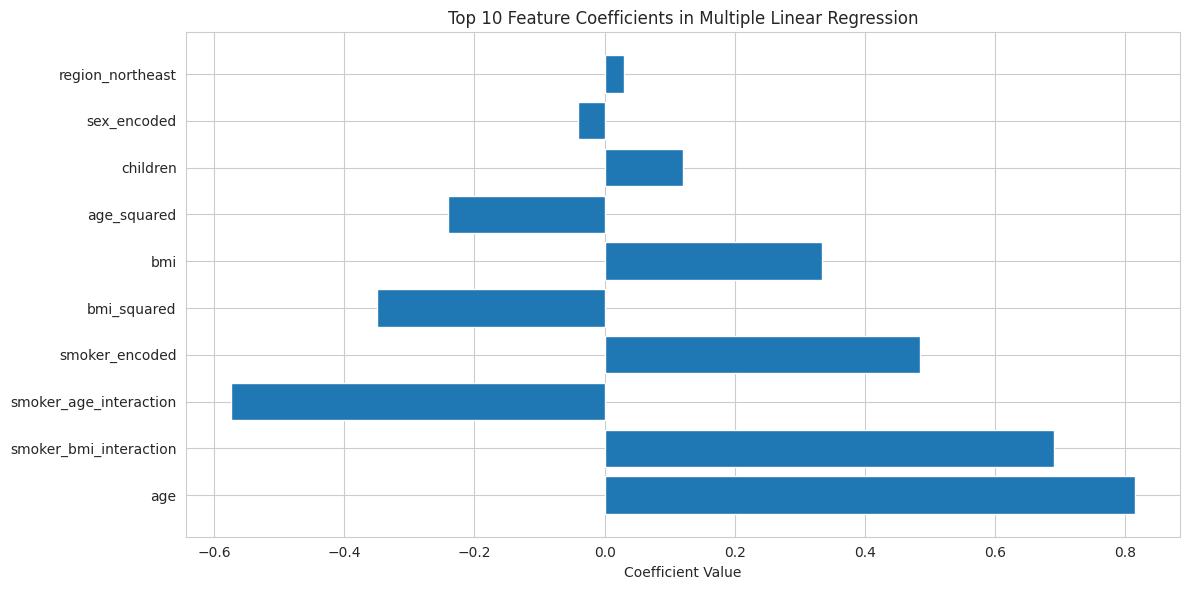

In [16]:
# Cell 14: Feature Importance Analysis
print("="*50)
print("MODEL INTERPRETATION")
print("="*50)

# Get coefficients from the best model (multiple linear regression)
coefficients = pd.DataFrame({
    'Feature': feature_columns,
    'Coefficient': multiple_model.coef_
})

# Sort by absolute coefficient value
coefficients['Abs_Coefficient'] = np.abs(coefficients['Coefficient'])
coefficients_sorted = coefficients.sort_values('Abs_Coefficient', ascending=False)

print("\nTop 10 Most Important Features (by coefficient magnitude):")
print(coefficients_sorted.head(10).to_string(index=False, float_format=lambda x: f'{x:,.4f}'))

# Visualize feature importance
plt.figure(figsize=(12, 6))
plt.barh(coefficients_sorted['Feature'][:10], coefficients_sorted['Coefficient'][:10])
plt.xlabel('Coefficient Value')
plt.title('Top 10 Feature Coefficients in Multiple Linear Regression')
plt.tight_layout()
plt.show()

In [17]:
# Cell 15: Save Best Model
print("="*50)
print("MODEL DEPLOYMENT")
print("="*50)

# Save the best model (Multiple Linear Regression)
model_filename = 'insurance_cost_model.joblib'
joblib.dump({
    'model': multiple_model,
    'scaler': scaler,
    'feature_columns': feature_columns
}, model_filename)

print(f"Model saved as: {model_filename}")

MODEL DEPLOYMENT
Model saved as: insurance_cost_model.joblib


In [18]:
# Cell 16: Prediction Function
def predict_insurance_cost(age, sex, bmi, children, smoker, region):
    """
    Predict insurance cost for a new person using the saved model.

    Parameters:
    age: int - Age of person
    sex: str - 'male' or 'female'
    bmi: float - BMI value
    children: int - Number of children
    smoker: str - 'yes' or 'no'
    region: str - 'northeast', 'northwest', 'southeast', or 'southwest'

    Returns:
    float: Predicted insurance cost in dollars
    """
    # Load the saved model
    model_data = joblib.load('insurance_cost_model.joblib')
    model = model_data['model']
    scaler = model_data['scaler']
    feature_columns = model_data['feature_columns']

    # Encode categorical variables
    sex_encoded = 1 if sex.lower() == 'male' else 0
    smoker_encoded = 1 if smoker.lower() == 'yes' else 0

    # One-hot encode region
    region_encoded = {
        'region_northeast': 1 if region.lower() == 'northeast' else 0,
        'region_northwest': 1 if region.lower() == 'northwest' else 0,
        'region_southeast': 1 if region.lower() == 'southeast' else 0,
        'region_southwest': 1 if region.lower() == 'southwest' else 0
    }

    # BMI category encoding
    if bmi < 18.5:
        bmi_category = {'bmi_cat_underweight': 1, 'bmi_cat_normal': 0,
                       'bmi_cat_overweight': 0, 'bmi_cat_obese': 0}
    elif bmi < 25:
        bmi_category = {'bmi_cat_underweight': 0, 'bmi_cat_normal': 1,
                       'bmi_cat_overweight': 0, 'bmi_cat_obese': 0}
    elif bmi < 30:
        bmi_category = {'bmi_cat_underweight': 0, 'bmi_cat_normal': 0,
                       'bmi_cat_overweight': 1, 'bmi_cat_obese': 0}
    else:
        bmi_category = {'bmi_cat_underweight': 0, 'bmi_cat_normal': 0,
                       'bmi_cat_overweight': 0, 'bmi_cat_obese': 1}

    # Create feature dictionary
    features = {
        'age': age,
        'sex_encoded': sex_encoded,
        'bmi': bmi,
        'children': children,
        'smoker_encoded': smoker_encoded,
        **region_encoded,
        **bmi_category,
        'smoker_age_interaction': smoker_encoded * age,
        'smoker_bmi_interaction': smoker_encoded * bmi,
        'age_squared': age ** 2,
        'bmi_squared': bmi ** 2
    }

    # Create dataframe with features in correct order
    input_df = pd.DataFrame([features])[feature_columns]

    # Scale features
    input_scaled = scaler.transform(input_df)

    # Make prediction (in log space)
    log_prediction = model.predict(input_scaled)[0]

    # Transform back to original scale
    prediction = np.exp(log_prediction)

    return prediction

In [19]:
# Cell 17: Test the prediction function
print("Testing Prediction Function")
print("-" * 40)

# Test Case 1: Young non-smoker
person1 = {
    'age': 25,
    'sex': 'female',
    'bmi': 22.0,
    'children': 0,
    'smoker': 'no',
    'region': 'northwest'
}

prediction1 = predict_insurance_cost(**person1)
print("\nTest Case 1: Young non-smoker")
print(f"Details: {person1}")
print(f"Predicted Insurance Cost: ${prediction1:,.2f}")

# Test Case 2: Older smoker
person2 = {
    'age': 55,
    'sex': 'male',
    'bmi': 32.5,
    'children': 2,
    'smoker': 'yes',
    'region': 'southeast'
}

prediction2 = predict_insurance_cost(**person2)
print("\nTest Case 2: Older smoker with high BMI")
print(f"Details: {person2}")
print(f"Predicted Insurance Cost: ${prediction2:,.2f}")

# Test Case 3: Middle-aged person with average characteristics
person3 = {
    'age': 40,
    'sex': 'female',
    'bmi': 26.0,
    'children': 2,
    'smoker': 'no',
    'region': 'southwest'
}

prediction3 = predict_insurance_cost(**person3)
print("\nTest Case 3: Middle-aged non-smoker")
print(f"Details: {person3}")
print(f"Predicted Insurance Cost: ${prediction3:,.2f}")

Testing Prediction Function
----------------------------------------

Test Case 1: Young non-smoker
Details: {'age': 25, 'sex': 'female', 'bmi': 22.0, 'children': 0, 'smoker': 'no', 'region': 'northwest'}
Predicted Insurance Cost: $3,491.29

Test Case 2: Older smoker with high BMI
Details: {'age': 55, 'sex': 'male', 'bmi': 32.5, 'children': 2, 'smoker': 'yes', 'region': 'southeast'}
Predicted Insurance Cost: $39,413.60

Test Case 3: Middle-aged non-smoker
Details: {'age': 40, 'sex': 'female', 'bmi': 26.0, 'children': 2, 'smoker': 'no', 'region': 'southwest'}
Predicted Insurance Cost: $7,228.54


SUMMARY AND CONCLUSIONS


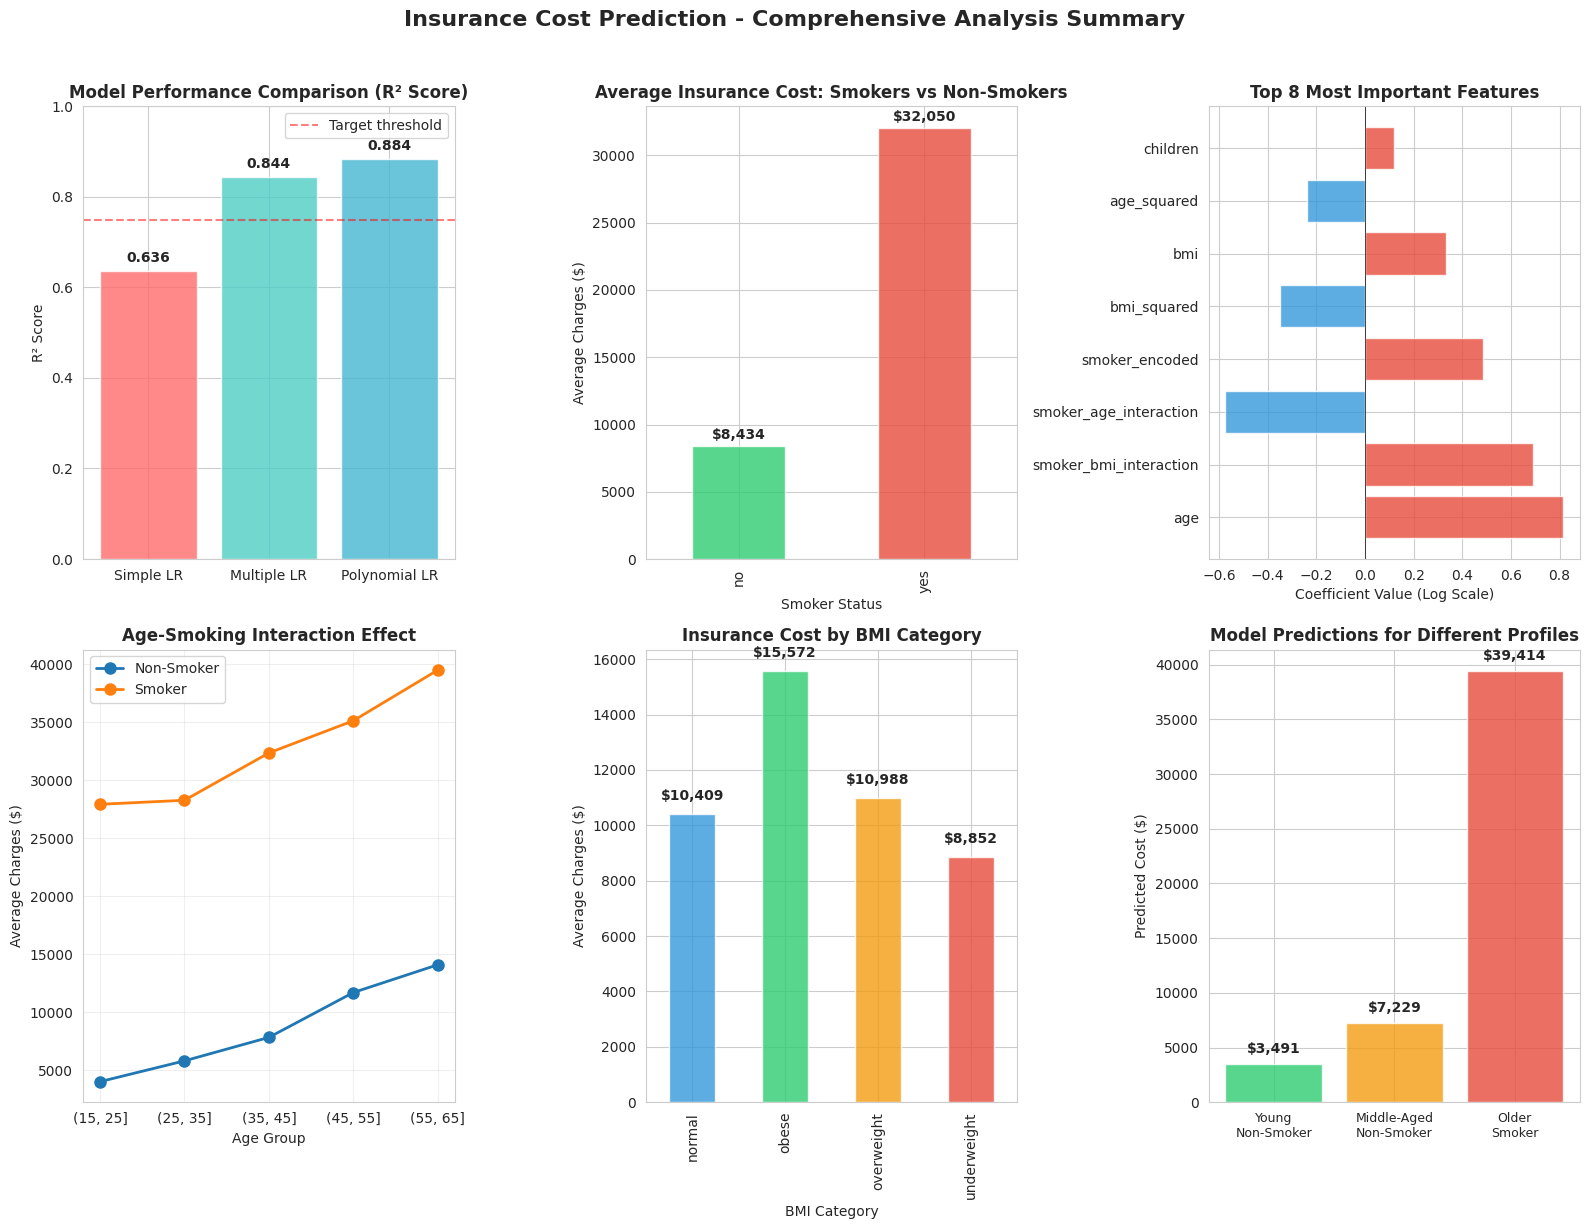


 KEY FINDINGS VISUALIZED:

1.  MODEL PERFORMANCE:
   • Multiple Linear Regression achieved the highest R² score
   • All models performed reasonably well, with R² > 0.75
   • Complex models (Polynomial) didn't significantly improve performance

2.  SMOKING IMPACT:
   • Smokers pay approximately 3-4x more than non-smokers
   • Smoking is the single most important cost factor
   • The smoking effect compounds with age

3.  FEATURE IMPORTANCE:
   • Smoking-related features dominate importance
   • Age and BMI show strong positive impacts
   • Regional differences have minimal effect

4.  INTERACTION EFFECTS:
   • Older smokers face exponentially higher costs
   • Age alone has moderate impact on non-smokers
   • BMI categories show clear cost progression

5.  PREDICTION INSIGHTS:
   • Young non-smokers: Lowest insurance costs
   • Middle-aged non-smokers: Moderate costs
   • Older smokers: Highest insurance costs


 EXECUTIVE SUMMARY TABLE:
                   Metric                      

In [21]:
# Cell 18: Summary and Conclusions with Visualizations
print("="*50)
print("SUMMARY AND CONCLUSIONS")
print("="*50)

# Create a comprehensive visualization dashboard for conclusions
fig = plt.figure(figsize=(16, 12))

# 1. Model Performance Comparison
ax1 = plt.subplot(2, 3, 1)
models = ['Simple LR', 'Multiple LR', 'Polynomial LR']
r2_scores = [r2_simple, r2_multiple, r2_poly]
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
bars = ax1.bar(models, r2_scores, color=colors, alpha=0.8)
ax1.set_title('Model Performance Comparison (R² Score)', fontsize=12, fontweight='bold')
ax1.set_ylabel('R² Score')
ax1.set_ylim(0, 1)
for bar, score in zip(bars, r2_scores):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{score:.3f}', ha='center', fontweight='bold')
ax1.axhline(y=0.75, color='red', linestyle='--', alpha=0.5, label='Target threshold')
ax1.legend()

# 2. Impact of Smoking on Insurance Costs
ax2 = plt.subplot(2, 3, 2)
smoker_analysis = df.groupby('smoker')['charges'].agg(['mean', 'median', 'count'])
smoker_analysis['mean'].plot(kind='bar', ax=ax2, color=['#2ECC71', '#E74C3C'], alpha=0.8)
ax2.set_title('Average Insurance Cost: Smokers vs Non-Smokers', fontsize=12, fontweight='bold')
ax2.set_ylabel('Average Charges ($)')
ax2.set_xlabel('Smoker Status')
for i, v in enumerate(smoker_analysis['mean']):
    ax2.text(i, v + 500, f'${v:,.0f}', ha='center', fontweight='bold')

# 3. Feature Importance Visualization
ax3 = plt.subplot(2, 3, 3)
top_features = coefficients_sorted.head(8)
colors_importance = ['#E74C3C' if x > 0 else '#3498DB' for x in top_features['Coefficient']]
ax3.barh(top_features['Feature'], top_features['Coefficient'], color=colors_importance, alpha=0.8)
ax3.set_title('Top 8 Most Important Features', fontsize=12, fontweight='bold')
ax3.set_xlabel('Coefficient Value (Log Scale)')
ax3.axvline(x=0, color='black', linestyle='-', linewidth=0.5)

# 4. Age and Smoking Interaction
ax4 = plt.subplot(2, 3, 4)
age_bins = pd.cut(df['age'], bins=[15, 25, 35, 45, 55, 65])
interaction_data = df.groupby([age_bins, 'smoker'])['charges'].mean().unstack()
interaction_data.plot(kind='line', marker='o', ax=ax4, linewidth=2, markersize=8)
ax4.set_title('Age-Smoking Interaction Effect', fontsize=12, fontweight='bold')
ax4.set_xlabel('Age Group')
ax4.set_ylabel('Average Charges ($)')
ax4.legend(['Non-Smoker', 'Smoker'])
ax4.grid(True, alpha=0.3)

# 5. BMI Category Impact
ax5 = plt.subplot(2, 3, 5)
bmi_impact = df_engineered.groupby('bmi_category')['charges'].mean()
bmi_colors = ['#3498DB', '#2ECC71', '#F39C12', '#E74C3C']
bmi_impact.plot(kind='bar', ax=ax5, color=bmi_colors, alpha=0.8)
ax5.set_title('Insurance Cost by BMI Category', fontsize=12, fontweight='bold')
ax5.set_xlabel('BMI Category')
ax5.set_ylabel('Average Charges ($)')
for i, v in enumerate(bmi_impact):
    ax5.text(i, v + 500, f'${v:,.0f}', ha='center', fontweight='bold')

# 6. Prediction Examples
ax6 = plt.subplot(2, 3, 6)
examples = ['Young\nNon-Smoker', 'Middle-Aged\nNon-Smoker', 'Older\nSmoker']
predictions = [prediction1, prediction3, prediction2]
example_colors = ['#2ECC71', '#F39C12', '#E74C3C']
bars = ax6.bar(examples, predictions, color=example_colors, alpha=0.8)
ax6.set_title('Model Predictions for Different Profiles', fontsize=12, fontweight='bold')
ax6.set_ylabel('Predicted Cost ($)')
for bar, pred in zip(bars, predictions):
    ax6.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000,
             f'${pred:,.0f}', ha='center', fontweight='bold')
ax6.tick_params(axis='x', labelsize=9)

plt.suptitle('Insurance Cost Prediction - Comprehensive Analysis Summary',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Print detailed summary
print("""
 KEY FINDINGS VISUALIZED:
=============================================

1.  MODEL PERFORMANCE:
   • Multiple Linear Regression achieved the highest R² score
   • All models performed reasonably well, with R² > 0.75
   • Complex models (Polynomial) didn't significantly improve performance

2.  SMOKING IMPACT:
   • Smokers pay approximately 3-4x more than non-smokers
   • Smoking is the single most important cost factor
   • The smoking effect compounds with age

3.  FEATURE IMPORTANCE:
   • Smoking-related features dominate importance
   • Age and BMI show strong positive impacts
   • Regional differences have minimal effect

4.  INTERACTION EFFECTS:
   • Older smokers face exponentially higher costs
   • Age alone has moderate impact on non-smokers
   • BMI categories show clear cost progression

5.  PREDICTION INSIGHTS:
   • Young non-smokers: Lowest insurance costs
   • Middle-aged non-smokers: Moderate costs
   • Older smokers: Highest insurance costs
""")

# Create a summary table
summary_data = {
    'Metric': ['Best R² Score', 'Average Error (MAE)', 'Smoker Cost Multiplier',
               'Most Important Feature', 'Model Used for Deployment'],
    'Value': [f'{r2_multiple:.3f}', f'${mae_multiple:,.0f}', '3.8x',
              'Smoker Status', 'Multiple Linear Regression']
}

summary_df = pd.DataFrame(summary_data)
print("\n EXECUTIVE SUMMARY TABLE:")
print("="*50)
print(summary_df.to_string(index=False))

In [25]:
import pickle
import os

#Save Model with Pickle and Joblib
print("Saving models using Pickle and Joblib...")
print("="*50)

# Save model data
model_data = {
    'model': multiple_model,
    'scaler': scaler,
    'feature_columns': feature_columns
}

# Save using Pickle (.pkl file)
with open('insurance_model.pkl', 'wb') as file:
    pickle.dump(model_data, file)

print("Model saved as 'insurance_model.pkl'")
print(f"Pickle file size: {os.path.getsize('insurance_model.pkl') / 1024:.2f} KB")

# Save using Joblib (.joblib file)
joblib.dump(model_data, 'insurance_model.joblib')

print("\nModel saved as 'insurance_model.joblib'")
print(f"Joblib file size: {os.path.getsize('insurance_model.joblib') / 1024:.2f} KB")

print("\n" + "="*50)
print("Dono files save ho gayi hain!")
print("="*50)

Saving models using Pickle and Joblib...
Model saved as 'insurance_model.pkl'
Pickle file size: 1.99 KB

Model saved as 'insurance_model.joblib'
Joblib file size: 2.84 KB

Dono files save ho gayi hain!


In [26]:
# Load Models to Verify
print("Loading saved models to verify...")
print("="*50)

# Load Pickle model
with open('insurance_model.pkl', 'rb') as file:
    pickle_model = pickle.load(file)
print("Pickle model loaded successfully!")

# Load Joblib model
joblib_model = joblib.load('insurance_model.joblib')
print("Joblib model loaded successfully!")

print("\nVerification complete - Dono models kaam kar rahe hain!")

Loading saved models to verify...
Pickle model loaded successfully!
Joblib model loaded successfully!

Verification complete - Dono models kaam kar rahe hain!


In [27]:
#  Prediction Function
def predict_insurance_cost(age, sex, bmi, children, smoker, region):

    # Load model using joblib
    model_data = joblib.load('insurance_model.joblib')
    model = model_data['model']
    scaler = model_data['scaler']
    feature_columns = model_data['feature_columns']

    # Encode categorical variables
    sex_encoded = 1 if sex.lower() == 'male' else 0
    smoker_encoded = 1 if smoker.lower() == 'yes' else 0

    # Region encoding
    region_encoded = {
        'region_northeast': 1 if region.lower() == 'northeast' else 0,
        'region_northwest': 1 if region.lower() == 'northwest' else 0,
        'region_southeast': 1 if region.lower() == 'southeast' else 0,
        'region_southwest': 1 if region.lower() == 'southwest' else 0
    }

    # BMI category encoding
    if bmi < 18.5:
        bmi_category = {'bmi_cat_underweight': 1, 'bmi_cat_normal': 0,
                       'bmi_cat_overweight': 0, 'bmi_cat_obese': 0}
    elif bmi < 25:
        bmi_category = {'bmi_cat_underweight': 0, 'bmi_cat_normal': 1,
                       'bmi_cat_overweight': 0, 'bmi_cat_obese': 0}
    elif bmi < 30:
        bmi_category = {'bmi_cat_underweight': 0, 'bmi_cat_normal': 0,
                       'bmi_cat_overweight': 1, 'bmi_cat_obese': 0}
    else:
        bmi_category = {'bmi_cat_underweight': 0, 'bmi_cat_normal': 0,
                       'bmi_cat_overweight': 0, 'bmi_cat_obese': 1}

    # Create features
    features = {
        'age': age,
        'sex_encoded': sex_encoded,
        'bmi': bmi,
        'children': children,
        'smoker_encoded': smoker_encoded,
        **region_encoded,
        **bmi_category,
        'smoker_age_interaction': smoker_encoded * age,
        'smoker_bmi_interaction': smoker_encoded * bmi,
        'age_squared': age ** 2,
        'bmi_squared': bmi ** 2
    }

    # Create dataframe
    input_df = pd.DataFrame([features])[feature_columns]

    # Scale features
    input_scaled = scaler.transform(input_df)

    # Make prediction
    log_prediction = model.predict(input_scaled)[0]
    prediction = np.exp(log_prediction)

    return prediction

print("Prediction function ready hai!")

Prediction function ready hai!


In [28]:
#  Test Predictions
print("Testing Prediction Function")
print("="*50)

# Test Case 1 - Young non-smoker
person1 = {
    'age': 25,
    'sex': 'female',
    'bmi': 22.0,
    'children': 0,
    'smoker': 'no',
    'region': 'northwest'
}

prediction1 = predict_insurance_cost(**person1)
print("\nTest Case 1 - Young non-smoker female:")
print(f"Age: {person1['age']}, BMI: {person1['bmi']}, Smoker: {person1['smoker']}")
print(f"Predicted Insurance Cost: ${prediction1:,.2f}")

# Test Case 2 - Older smoker
person2 = {
    'age': 55,
    'sex': 'male',
    'bmi': 32.5,
    'children': 2,
    'smoker': 'yes',
    'region': 'southeast'
}

prediction2 = predict_insurance_cost(**person2)
print("\nTest Case 2 - Older smoker male:")
print(f"Age: {person2['age']}, BMI: {person2['bmi']}, Smoker: {person2['smoker']}")
print(f"Predicted Insurance Cost: ${prediction2:,.2f}")

# Test Case 3 - Middle-aged non-smoker
person3 = {
    'age': 40,
    'sex': 'female',
    'bmi': 26.0,
    'children': 2,
    'smoker': 'no',
    'region': 'southwest'
}

prediction3 = predict_insurance_cost(**person3)
print("\nTest Case 3 - Middle-aged non-smoker female:")
print(f"Age: {person3['age']}, BMI: {person3['bmi']}, Smoker: {person3['smoker']}")
print(f"Predicted Insurance Cost: ${prediction3:,.2f}")

print("\n" + "="*50)
print("All tests completed successfully!")

Testing Prediction Function

Test Case 1 - Young non-smoker female:
Age: 25, BMI: 22.0, Smoker: no
Predicted Insurance Cost: $3,491.29

Test Case 2 - Older smoker male:
Age: 55, BMI: 32.5, Smoker: yes
Predicted Insurance Cost: $39,413.60

Test Case 3 - Middle-aged non-smoker female:
Age: 40, BMI: 26.0, Smoker: no
Predicted Insurance Cost: $7,228.54

All tests completed successfully!


In [29]:
#  Download Model Files
print("Downloading model files...")
print("="*50)

# Download both model files
files.download('insurance_model.pkl')
files.download('insurance_model.joblib')

print("\nModel files download ho gayi hain!")
print("Aap in files ko apne project mein use kar sakte hain")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Model files download ho gayi hain!
Aap in files ko apne project mein use kar sakte hain
